In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [10]:
def fill_func(x, size):
    vec = [size]
    idx = np.arange(size)
    #rng = np.random.default_rng(seed)
    #rand_coeffs = rng.random(size)
    vec = x(idx)
    
    return vec 

In [23]:
# x = lambda x : ( np.cos(3*x) - ( 0.2 * np.sin(x)) ) 

x = lambda x : (np.cos(x)) +1

vec = fill_func(x, 1000)

print(vec)

[2.00000000e+00 1.54030231e+00 5.83853163e-01 1.00075034e-02
 3.46356379e-01 1.28366219e+00 1.96017029e+00 1.75390225e+00
 8.54499966e-01 8.88697381e-02 1.60928471e-01 1.00442570e+00
 1.84385396e+00 1.90744678e+00 1.13673722e+00 2.40312087e-01
 4.23405197e-02 7.24836662e-01 1.66031671e+00 1.98870462e+00
 1.40808206e+00 4.52270740e-01 3.91736054e-05 4.67166980e-01
 1.42417901e+00 1.99120281e+00 1.64691932e+00 7.07861191e-01
 3.73941337e-02 2.51942470e-01 1.15425145e+00 1.91474236e+00
 1.83422336e+00 9.86723253e-01 1.51429725e-01 9.63077949e-02
 8.72036310e-01 1.76541405e+00 1.95507364e+00 1.26664293e+00
 3.33061938e-01 1.26607225e-02 6.00014685e-01 1.55511330e+00
 1.99984331e+00 1.52532199e+00 5.67822055e-01 7.66453085e-03
 3.59855661e-01 1.30059254e+00 1.96496603e+00 1.74215420e+00
 8.37009219e-01 8.17172138e-02 1.70690167e-01 1.02212676e+00
 1.85322011e+00 1.89986683e+00 1.11918014e+00 2.28919777e-01
 4.75870196e-02 7.41898364e-01 1.67350716e+00 1.98589658e+00
 1.39185723e+00 4.375461

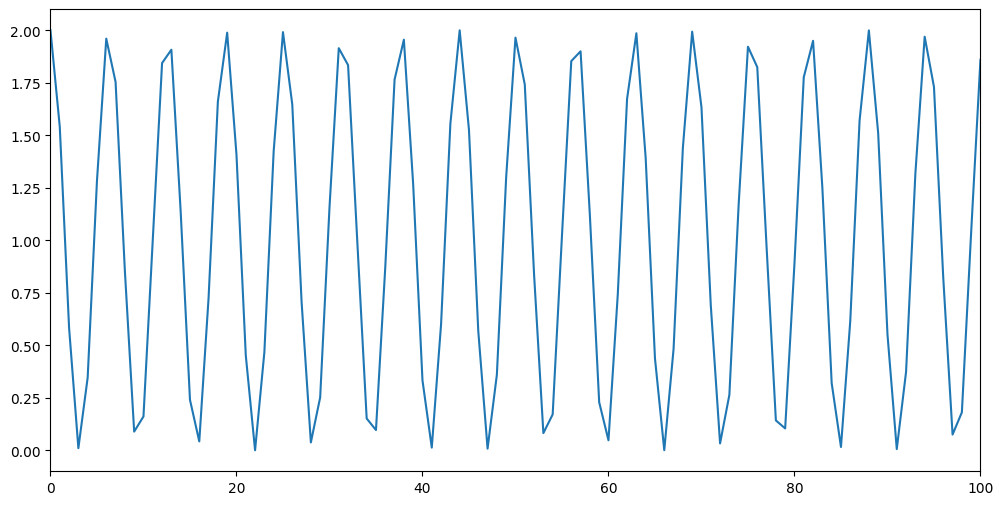

In [26]:
fig, ax = plt.subplots(figsize=(12,6))

#ax.set_ylim(-2,2)
ax.set_xlim(0,100)
ax.plot(vec)


In [27]:
def train_LR(data):
    x = np.array(list(data.keys()))
    y = np.array(list(data.values()))
    
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    num = np.sum( ( x - x_mean) * (y - y_mean) )
    denominator = np.sum( (x - x_mean) ** 2)
    
    beta = num / denominator
    
    alpha = y_mean - (beta * x_mean)
    
    return alpha, beta

def predict_next(next_x, alpha, beta):
    return alpha + beta * next_x



In [55]:
x = lambda x : 1 + x ** 100 / (1 + np.e ** x)
x_2 = lambda x : 0.5 * x + 10 + np.random.rand()

vec = fill_func(x, 10_000)
vec_2 = fill_func(x_2, 10_000)

print(len(vec_2))

10000


/tmp/ipykernel_2472322/387847201.py:1: RuntimeWarning: overflow encountered in power
  x = lambda x : 1 + x ** 100 / (1 + np.e ** x)


In [57]:
#dict_1 = fill_dict(vec_2)
dict_1 = dict(enumerate(vec))
dict_2 = dict(enumerate(vec_2))
#dict_1

In [82]:

vec_3 = [0] * 11_000

for i in range(len(vec_3)):
    if i > 9_999:
        vec_3[i] = 0
    else:
        vec_3[i] = vec_2[i]
    
len(vec_3)

11000

In [93]:
alpha , beta = train_LR(dict_2)

print(predict_next(10_001, alpha, beta))
#dict_3 = dict(enumerate(vec_3))
for i in range(len(vec_3)):
    
    if i < 9_999:
        pass
    else:
        vec_3[i] = predict_next(i, alpha, beta)

vec_3[10_500]

dict_3 = dict(enumerate(vec_3))



5011.304747798179


5260.804747798179

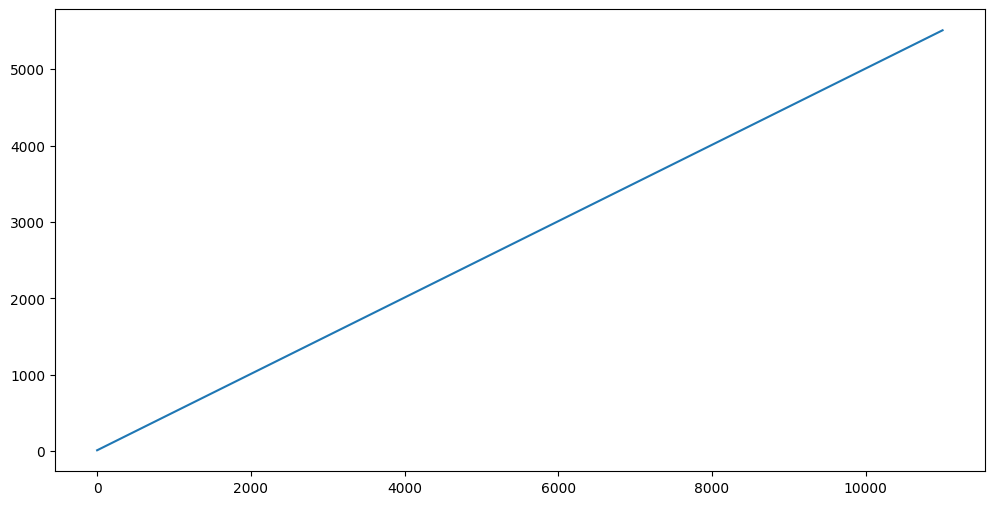

In [94]:
fig,ax = plt.subplots(figsize=(12,6))

ax.plot(vec_3)

### Outra roupagem
Agora vamos fazer com o sklearn 

In [30]:
import yfinance as yf
from sklearn.linear_model import LinearRegression

In [86]:
stocks = ['NVDA','AAPL','MSFT','AVGO','MU','ORCL','CSCO','AMD','PLTR','IBM','LRCX','INTC','SAP']

def collect_info(stock):
    
    src = yf.Ticker(stock)
    vec = src.history(period="3mo")['Close']
    
    return vec

In [74]:
vec = collect_info(stocks[1])

print(vec)

vec = vec[1:]

#vec2 = [0] * ( len(vec) - 1 )

Date
2025-11-10 00:00:00-05:00           NaN
2025-11-11 00:00:00-05:00    274.992676
2025-11-12 00:00:00-05:00    273.214355
2025-11-13 00:00:00-05:00    272.694855
2025-11-14 00:00:00-05:00    272.155334
                                ...    
2026-02-04 00:00:00-05:00    276.231506
2026-02-05 00:00:00-05:00    275.652069
2026-02-06 00:00:00-05:00    277.859985
2026-02-09 00:00:00-05:00    274.619995
2026-02-10 00:00:00-05:00    273.679993
Name: Close, Length: 63, dtype: float64


In [82]:
vec_x = [i for i in range(len(vec))]
vec_x2 = dict(enumerate(vec))
vec2 = np.array(list(vec_x2.items()))

X = vec2[:, 0].reshape(-1, 1)
Y = vec2[:, 1]

model = LinearRegression()
model.fit(X, Y)
y_pred = model.predict(X)

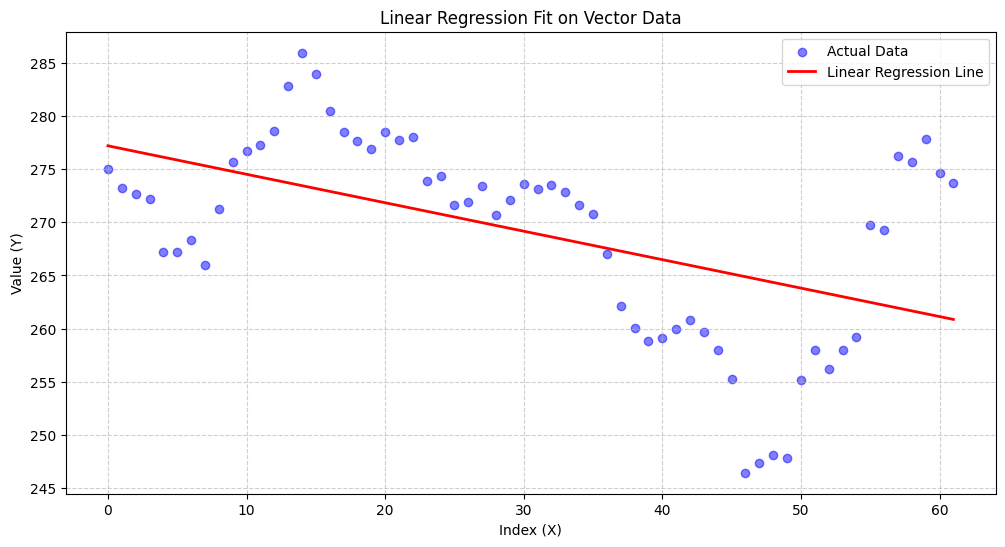

In [83]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(X, Y, color='blue', label='Actual Data', alpha=0.5)

ax.plot(X, y_pred, color='red', linewidth=2, label='Linear Regression Line')

ax.set_xlabel("Index (X)")
ax.set_ylabel("Value (Y)")
ax.set_title("Linear Regression Fit on Vector Data")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [91]:
stock = collect_info(stocks[2])

stock[61]

/tmp/ipykernel_2582823/508995679.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  stock[61]


413.2699890136719

In [1]:
# CmGNTaRPIp3keeRqQZ7I4Pdku8kJ7WSp

from mistralai import Mistral
import os


with Mistral(
    api_key=os.getenv("MISTRAL_API_KEY", "CmGNTaRPIp3keeRqQZ7I4Pdku8kJ7WSp"),
) as mistral:

    res = mistral.chat.complete(model="mistral-small-latest", messages=[
        {
            "content": "Who is the best French painter? Answer in one short sentence.",
            "role": "user",
        },
    ], stream=False)

    print(res.choices[0].message.content)

resp = res['choices'][0]['message']['content']

id='a379e208db3c44a68b86054a20120eaf' object='chat.completion' model='mistral-small-latest' usage=UsageInfo(prompt_tokens=16, completion_tokens=12, total_tokens=28, prompt_audio_seconds=Unset(), num_cached_tokens=0) created=1770635539 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(content='Claude Monet is often considered the best French painter.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


In [ ]:
Atualização do ambiente do inventory para testes do rabbitMQ




Tag backend -> hml-1.1.0




tag front-end->  hml-1.1.0




não há migrações 




Variáveis de ambiente 

RABBITMQ_HOST = "a1db9522561a74280b057f306c4b17f5-2041058484.us-east-1.elb.amazonaws.com"
RABBITMQ_PORT = 5672
RABBITMQ_USERNAME = "admin"
RABBITMQ_PASSWORD = "asdf123$"


